In [1]:
import pandas as pd
import missingno as msno
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
def concat_data():
    mechanisms = ['MCAR', 'MAR_l','MAR_mix', 'MAR_h', 'MNAR_l', 'MNAR_h']
    data = {}
    for miss in ['05','10','15','20','25']:
        data[miss] = []
        for mech in mechanisms:
            path = f"COVID-19-Wearables-Missing/{mech}/AAXAA7Z/1"
            df = pd.read_csv(os.path.join(path, f"AAXAA7Z_hr_{mech}_1_{miss}.csv"))
            df['mechanism'] = mech
            df['miss'] = miss + '%'
            data[miss].append(df)

    dist = {}
    for miss, dfs in data.items():
        dist[miss] = []
        for df in dfs:
            nan_indices = df[df['heartrate'].isna()].index
            target_values = df.loc[nan_indices, ['target', 'mechanism', 'miss']]
            print(f"Missing: {miss}, Mechanism: {df['mechanism'].iloc[0]}, Missing Values: {len(nan_indices)}")
            dist[miss].append(target_values)
        dist[miss] = pd.concat(dist[miss], ignore_index=True)

    df_all = pd.concat([dist[miss] for miss in dist], ignore_index=True)
    return df_all, dist


df_all, df_miss = concat_data()


Missing: 05, Mechanism: MCAR, Missing Values: 31234
Missing: 05, Mechanism: MAR_l, Missing Values: 31234
Missing: 05, Mechanism: MAR_mix, Missing Values: 31234
Missing: 05, Mechanism: MAR_h, Missing Values: 31234
Missing: 05, Mechanism: MNAR_l, Missing Values: 31234
Missing: 05, Mechanism: MNAR_h, Missing Values: 31234
Missing: 10, Mechanism: MCAR, Missing Values: 60906
Missing: 10, Mechanism: MAR_l, Missing Values: 60906
Missing: 10, Mechanism: MAR_mix, Missing Values: 60906
Missing: 10, Mechanism: MAR_h, Missing Values: 60906
Missing: 10, Mechanism: MNAR_l, Missing Values: 60906
Missing: 10, Mechanism: MNAR_h, Missing Values: 60906
Missing: 15, Mechanism: MCAR, Missing Values: 89094
Missing: 15, Mechanism: MAR_l, Missing Values: 89094
Missing: 15, Mechanism: MAR_mix, Missing Values: 89094
Missing: 15, Mechanism: MAR_h, Missing Values: 89094
Missing: 15, Mechanism: MNAR_l, Missing Values: 89094
Missing: 15, Mechanism: MNAR_h, Missing Values: 89094
Missing: 20, Mechanism: MCAR, Missing

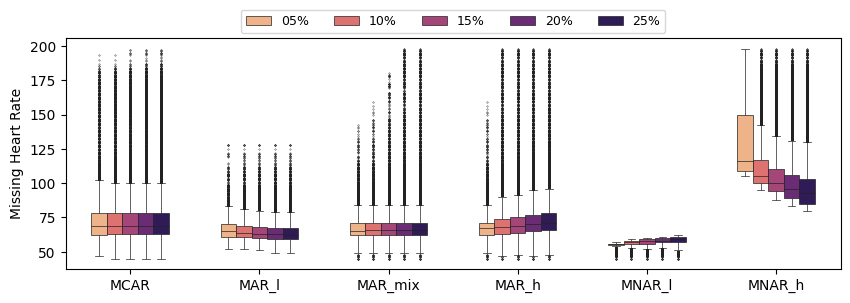

In [25]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df_all, x='mechanism', y='target', hue='miss', palette="magma_r", fliersize=0.3, linewidth=0.5, width=0.6)
plt.xlabel('')
plt.ylabel('Missing Heart Rate')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(df_all['miss'].unique()),fontsize=9)
plt.savefig('Plots/missing_boxplot_hros.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
df_mec = {}
for mec in ['MCAR','MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']:
    df_mec[mec] = [pd.read_csv(os.path.join(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1', f)) for f in sorted(os.listdir(f'COVID-19-Wearables-Missing/{mec}/AAXAA7Z/1')) if f.endswith('.csv')]

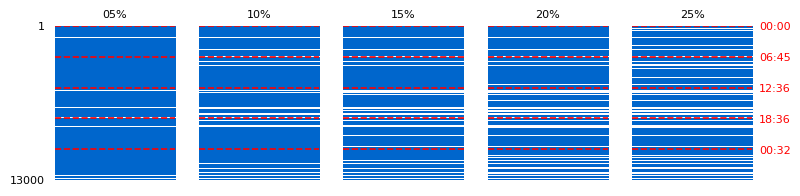

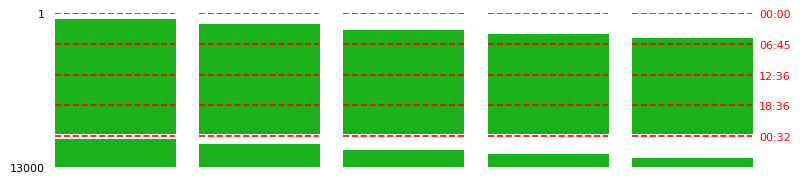

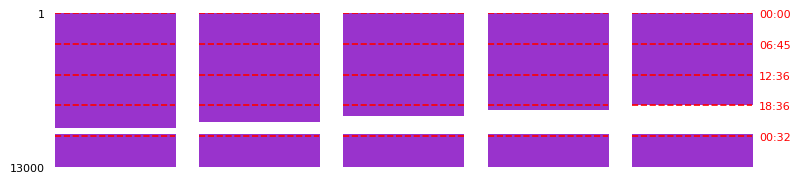

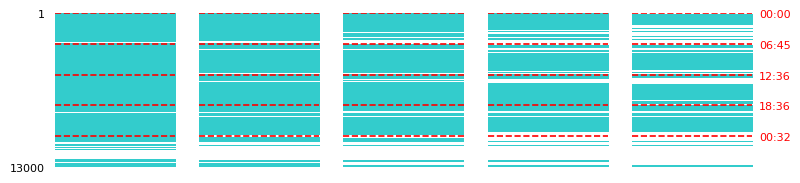

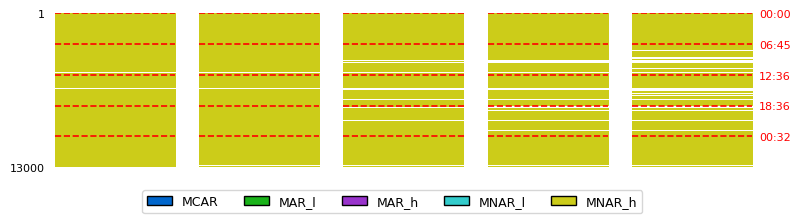

In [ ]:
from matplotlib.patches import Patch

color_map = {
    'MCAR': (0, 0.4, 0.8),      # blue
    'MAR_l': (0.1, 0.7, 0.1),   # green
    'MAR_h': (0.6, 0.2, 0.8),   # purple
    'MNAR_l': (0.2, 0.8, 0.8),  # cyan
    'MNAR_h': (0.8, 0.8, 0.1),  # yellow
}

N = 13000
D = 5
y_ticks = []

for j, (mec, dfs) in enumerate(df_mec.items()):
    fig, axes = plt.subplots(1, len(dfs), figsize=(9, 2))
    for i, (df, ax) in enumerate(zip(dfs, axes)):
        msno.matrix(df[['heartrate']][:N], sparkline=False, ax=ax, fontsize=7,labels="", color=color_map[mec])

        if j == 0:
            ax.set_title(f"{['05','10','15','20','25'][i]}%", fontsize=8)
        if i == 0:
            ax.get_yaxis().set_visible(True)
        elif i == 4:
            ticks = df.head(N).index[::int(N/D)]
            labels = pd.to_datetime(df["datetime"].head(N).iloc[::int(N/D)]).dt.strftime('%H:%M')
            ax.yaxis.tick_right()
            ax.tick_params(axis='y', pad=5, length=0)
            ax.set_yticks(ticks)
            ax.set_yticklabels(labels, fontsize=8, color='red')
            time_ticks = ticks
        else:
            ax.get_yaxis().set_visible(False)
    
    for y in time_ticks:
        for ax in axes:
            ax.axhline(y, color='red', linestyle='--', linewidth=1.2, alpha=1, zorder=10)

    if j == len(df_mec) - 1:
        legend_elements = [Patch(facecolor=color_map[key], edgecolor='k', label=key) for key in color_map]
        fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(color_map), fontsize=9)

    fig.savefig(
        f"Plots/{mec}_missing_matrix.png",
        dpi=300, bbox_inches='tight'
    )

In [26]:
from PIL import Image
import glob

# Get all PNG files in the directory, sorted by mechanism order
mechanism_order = ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']
img_paths = [f"Plots/{mec}_missing_matrix.png" for mec in mechanism_order]

# Open images
images = [Image.open(p) for p in img_paths]

# Calculate max width and total height for vertical concatenation
max_width = max(img.width for img in images)
total_height = sum(img.height for img in images)

# Create a new blank image for vertical stacking
combined_img = Image.new('RGB', (max_width, total_height), (255, 255, 255))

# Paste images one below the other
y_offset = 0
for img in images:
    combined_img.paste(img, (0, y_offset))
    y_offset += img.height

# Save the combined image
combined_img.save('Plots/missing_matrix_hros.png')